In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Makes charts look nice
sns.set_theme(style="darkgrid")
print("Libraries loaded successfully! ✅")

Libraries loaded successfully! ✅


In [2]:
df = pd.read_csv("netflix_titles.csv")
print("Shape:", df.shape)       # rows and columns
print("\nFirst 5 rows:")
df.head()

Shape: (8807, 12)

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# See all column names
print("Columns:", df.columns.tolist())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [4]:
# Fill missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)

# Drop rows where date_added is missing
df.dropna(subset=['date_added'], inplace=True)

# Clean date column and extract year
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print("Data cleaned! ✅")
print("New shape:", df.shape)

Data cleaned! ✅
New shape: (8797, 14)


C:\Users\Nagashri R\AppData\Local\Temp\ipykernel_22012\3946301271.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
C:\Users\Nagashri R\AppData\Local\Temp\ipykernel_22012\3946301271.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


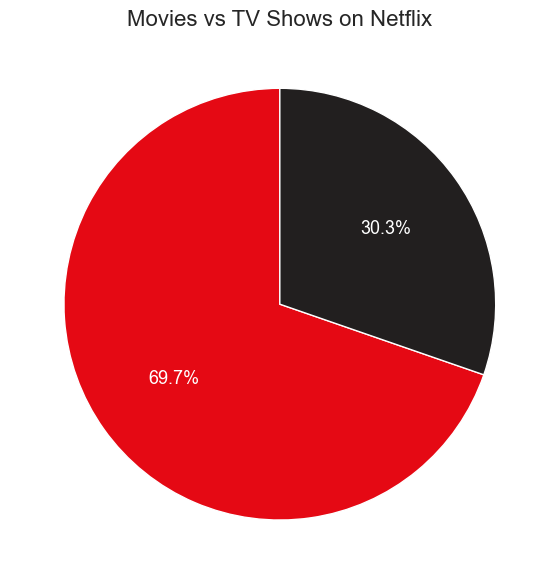

In [5]:
plt.figure(figsize=(6,6))
df['type'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#E50914', '#221F1F'],
    startangle=90,
    textprops={'color': 'white', 'fontsize': 13}
)
plt.title('Movies vs TV Shows on Netflix', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.savefig('movies_vs_shows.png')
plt.show()

C:\Users\Nagashri R\AppData\Local\Temp\ipykernel_22012\4043401844.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')


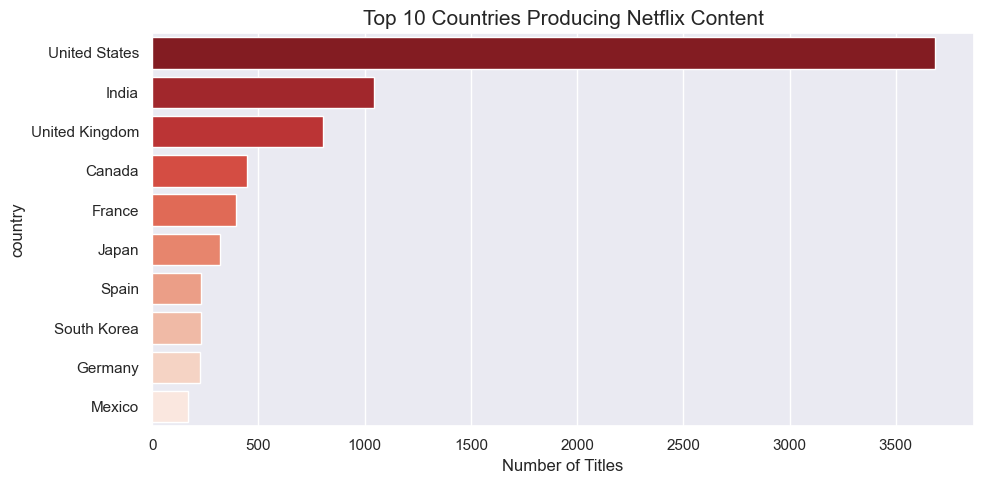

In [6]:
top_countries = df['country'].str.split(',').explode().str.strip()
top_countries = top_countries[top_countries != 'Unknown']
top_countries = top_countries.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 Countries Producing Netflix Content', fontsize=15)
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('top_countries.png')
plt.show()

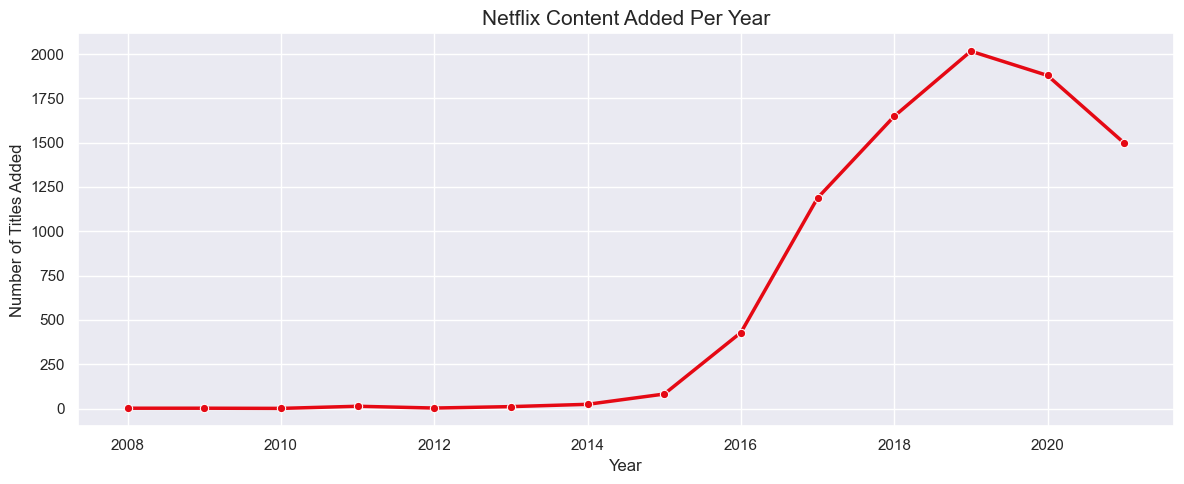

In [7]:
yearly = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,5))
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', color='#E50914', linewidth=2.5)
plt.title('Netflix Content Added Per Year', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.tight_layout()
plt.savefig('content_per_year.png')
plt.show()

C:\Users\Nagashri R\AppData\Local\Temp\ipykernel_22012\842781449.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='rocket')


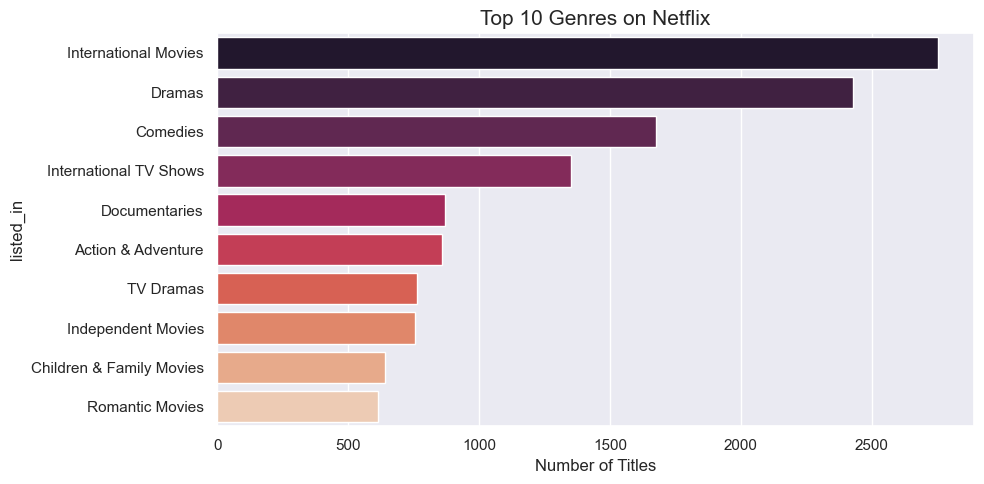

In [8]:
genres = df['listed_in'].str.split(',').explode().str.strip()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='rocket')
plt.title('Top 10 Genres on Netflix', fontsize=15)
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('top_genres.png')
plt.show()

C:\Users\Nagashri R\AppData\Local\Temp\ipykernel_22012\4029643483.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=rating_order, palette='magma')


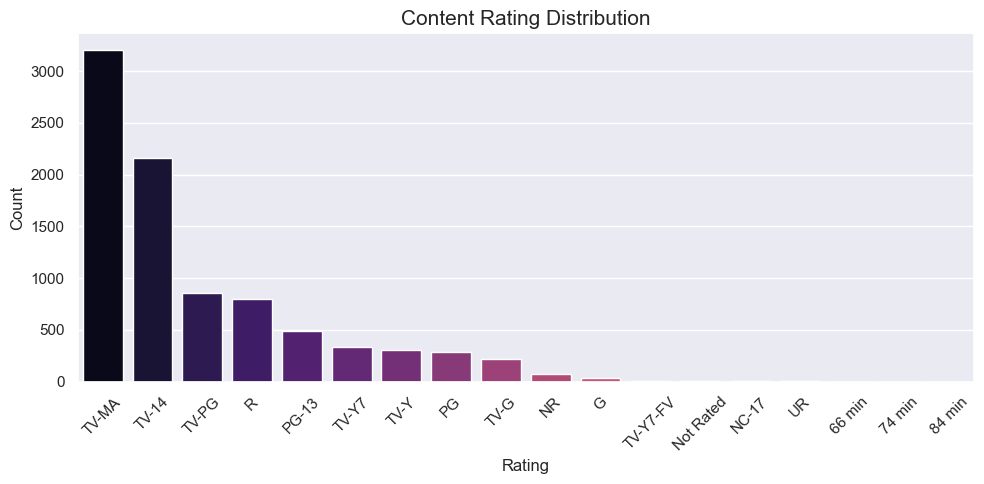

In [9]:
plt.figure(figsize=(10,5))
rating_order = df['rating'].value_counts().index
sns.countplot(data=df, x='rating', order=rating_order, palette='magma')
plt.title('Content Rating Distribution', fontsize=15)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ratings.png')
plt.show()

In [11]:
print("=" * 45)
print("       📊 NETFLIX DATA ANALYSIS SUMMARY")
print("=" * 45)
print(f"Total Titles: {df.shape[0]}")
print(f"Movies: {df[df['type']=='Movie'].shape[0]}")
print(f"TV Shows: {df[df['type']=='TV Show'].shape[0]}")
print(f"Top Country: {top_countries.index[0]}")
print(f"Most Common Rating: {df['rating'].mode()[0]}")
print(f"Best Year for Content: {yearly.idxmax()}")
print(f"Top Genre: {top_genres.index[0]}")
print("=" * 45)


       📊 NETFLIX DATA ANALYSIS SUMMARY
Total Titles: 8797
Movies: 6131
TV Shows: 2666
Top Country: United States
Most Common Rating: TV-MA
Best Year for Content: 2019
Top Genre: International Movies
